## O affect of none preprocessing experment

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_parquet('ds/shopping_queries_dataset_examples.parquet')

In [4]:
#to focus only on one locale like us

data = data[data['product_locale'] == 'us']
data = data.sample(n=10000, random_state=42).reset_index(drop=True)

#data info

print(f"shape: {data.shape}")
print()
print(data.dtypes)

shape: (10000, 9)

example_id         int64
query             object
query_id           int64
product_id        object
product_locale    object
esci_label        object
small_version      int64
large_version      int64
split             object
dtype: object


In [5]:
data.head(2)

,example_id,query,query_id,product_id,product_locale,esci_label,small_version,large_version,split
0,2219601,workout weights,113894,B07HGX6G9K,us,E,1,1,train
1,1452229,nintendo gift cards,73849,B00K59HKIQ,us,I,0,1,train


In [6]:
#drop unessery columns since we don t use other dataset

# and also since we d ont want to use product dataset and our goal is only categorise based on query it self we
# don t need to use esci (exact , , , ....) labelling
data = data.drop(columns=['example_id' , 'product_id' , 'query_id' , 'split' , 'product_locale' ,'esci_label' , 'small_version' , 'large_version'])

In [7]:
data.info()

#we have now only one columns query

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   query   10000 non-null  object
dtypes: object(1)
memory usage: 78.3+ KB


In [8]:
#convert obj to string 
data['query'] = data['query'].astype('string')

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   query   10000 non-null  string
dtypes: string(1)
memory usage: 78.3 KB


In [10]:
#geometrique Columns

# new columns from str columns
data['query_chars'] = data['query'].fillna('').str.len()
data['query_words'] = data['query'].fillna('').str.split().str.len()
#contain a number digit it could define or segment people the one that search for specifique like tv 50 inch 0 or  1
data['contains_digit'] = data['query'].str.contains(r'\d').astype(int)
#count digit
data['digit_count'] = data['query'].str.count(r'\d')

#average word length
data['avg_word_len'] = data['query_chars'] / data['query_words'].replace(0, 1)

#space count
data['space_count'] = data['query'].str.count(' ')

#special cracters count
data['spec_char_count'] = data['query'].str.count(r'[^a-zA-Z0-9\s]')

#upper case ratio no need everything low case
#data['upper_ratio'] = data['query'].str.findall(r'[A-Z]').str.len() / data['query_chars']


#since we are based on just query we tried to extract max info 

In [11]:
#semantic Column 

from sentence_transformers import SentenceTransformer

#it s a model that take a sentence and convert it to a vector of many dimmensions like dim1 take sentiment dim2 verb tense ....

#and this model contains 384 dimmension
# so simply it s a model takes text and convert to a numbre vector a meaning in math
#it s pretrained model with neural network


model = SentenceTransformer('all-MiniLM-L6-v2', device='cpu')

embeddings = model.encode(
    data['query'].tolist(),
    batch_size=256,
    show_progress_bar=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/40 [00:00<?, ?it/s]

In [12]:
embeddings.shape 

(10000, 384)

In [13]:
embeddings[:10]

array([[-0.09854124,  0.02925112, -0.03838247, ..., -0.05338418,
         0.05466885, -0.00704983],
       [-0.10397693,  0.02758895, -0.01266059, ...,  0.01229009,
        -0.02926036,  0.0277749 ],
       [ 0.01959759,  0.0281667 ,  0.07780294, ..., -0.05311717,
        -0.02972027,  0.03857833],
       ...,
       [-0.02815098,  0.06356686, -0.01280949, ...,  0.06591015,
         0.06059738,  0.04284479],
       [-0.08132516,  0.02135177,  0.00382381, ...,  0.03616343,
         0.02651393, -0.00765904],
       [-0.10501935, -0.08706877, -0.01861359, ..., -0.04824757,
         0.02824977, -0.04335204]], dtype=float32)

In [ ]:
from sklearn.preprocessing import normalize
from umap import UMAP

# reduce deminsions of embidings from 384 to 15
# no reducing of 
'''embeddings_norm = normalize(embeddings, norm='l2')

umap_model = UMAP(
    n_components=15,
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

emb_reduced = umap_model.fit_transform(embeddings_norm)'''

In [15]:
#save it to dataframe

emb_df = pd.DataFrame(
    embeddings, 
    columns=[f'emb_{i}' for i in range(embeddings.shape[1])]
)

In [16]:
geo_features = [
    'query_chars', 'query_words', 'contains_digit',
    'digit_count', 'avg_word_len', 'space_count', 'spec_char_count'
]

In [ ]:
from sklearn.preprocessing import StandardScaler

geo_cols = ['query_chars', 'query_words', 'contains_digit', 'digit_count' , 'avg_word_len' , 'space_count' , 'spec_char_count'] 

#no scalling
"""scaler = StandardScaler()
data[geo_cols] = scaler.fit_transform(data[geo_cols])"""

In [17]:
#save all to one dataframe

final_data = pd.concat(
    [data , emb_df],
    axis=1
)

In [18]:
final_data.head(8)

,query,query_chars,query_words,contains_digit,digit_count,avg_word_len,space_count,spec_char_count,emb_0,emb_1,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
0,workout weights,15,2,0,0,7.5,1,0,-0.098541,0.029251,...,0.005517,0.077500,-0.022549,-0.049219,-0.034567,0.031502,0.026932,-0.053384,0.054669,-0.007050
1,nintendo gift cards,19,3,0,0,6.333333,2,0,-0.103977,0.027589,...,-0.060453,-0.016155,0.031342,-0.043019,0.032355,-0.013949,-0.015801,0.012290,-0.029260,0.027775
2,urban skin rx,13,3,0,0,4.333333,2,0,0.019598,0.028167,...,0.027974,-0.074962,-0.046465,0.049866,0.004057,-0.018883,-0.026452,-0.053117,-0.029720,0.038578
3,bird seed,9,2,0,0,4.5,1,0,-0.040525,0.058530,...,0.034008,0.026916,-0.049340,-0.009326,0.061434,-0.011129,0.004949,-0.043648,-0.002826,0.031560
4,+foot cream without alcohol,27,4,0,0,6.75,3,1,-0.015869,0.020266,...,0.036035,-0.067035,0.031721,0.000500,0.000567,-0.010570,0.034120,-0.092036,0.130313,-0.029149
5,brother tn730 high yield black toner,36,6,1,3,6.0,5,0,-0.116949,0.064859,...,-0.062960,-0.084563,-0.061715,0.071372,-0.013159,0.022810,0.042173,-0.094805,-0.003054,-0.076723
6,60 lashes,9,2,1,2,4.5,1,0,-0.028892,0.037154,...,-0.011758,-0.057881,0.074509,-0.029323,-0.097337,-0.001138,0.108845,0.001163,0.044889,-0.039849
7,cpap filters,12,2,0,0,6.0,1,0,-0.028151,0.063567,...,-0.035132,0.010599,0.002780,-0.084297,0.007712,0.058618,0.060784,0.065910,0.060597,0.042845


In [19]:
final_data.to_csv("ds/test_no_prep.csv")

## only geo without preprocessing 

In [31]:

data = pd.read_csv('ds/test_no_prep.csv')

geo_cols = ['query_chars', 'query_words', 'contains_digit', 'digit_count' , 'avg_word_len' , 'space_count' , 'spec_char_count']
x = data[geo_cols]

x.head()

,query_chars,query_words,contains_digit,digit_count,avg_word_len,space_count,spec_char_count
0,15,2,0,0,7.500000,1,0
1,19,3,0,0,6.333333,2,0
2,13,3,0,0,4.333333,2,0
3,9,2,0,0,4.500000,1,0
4,27,4,0,0,6.750000,3,1


In [32]:

from sklearn.cluster import KMeans

#Kmeans expermint no preprocessing Model 

kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)

# predict
data['kmeans_cluster'] = kmeans_final.fit_predict(x)

# check clusters
print(data['kmeans_cluster'].value_counts())

kmeans_cluster
0    6461
1    3539
Name: count, dtype: int64


C:\Users\Original Computer\AppData\Local\Temp\ipykernel_1900\1030104497.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['kmeans_cluster'] = kmeans_final.fit_predict(x)


In [35]:
for i in range(2):
    print(f"\n--- Examples of Cluster {i} ---")
    print(data[data['kmeans_cluster'] == i]['query'].head(20).values)


--- Examples of Cluster 0 ---
<StringArray>
[        'workout weights',     'nintendo gift cards',
           'urban skin rx',               'bird seed',
               '60 lashes',            'cpap filters',
 'tumblers bulk wholesale',      'carhartt lined cap',
          'seat belt belt',         'lebel cosmetics',
      'dunkin donuts toys',        'new era snapback',
           'ironing board',           'iphone used 6',
           'black zipties', 'smartphone tripod mount',
   'compost bags 3 gallon',             'wood slices',
        'delta force book',          'white headband']
Length: 20, dtype: str

--- Examples of Cluster 1 ---
<StringArray>
[               '+foot cream without alcohol',
       'brother tn730 high yield black toner',
              'long cord lavalier microphone',
 'hyundai accent steering wheel sign sticker',
                 'bronze toilet paper holder',
                  'hot pink berets for women',
                  'coffee grinder fine gring',
        

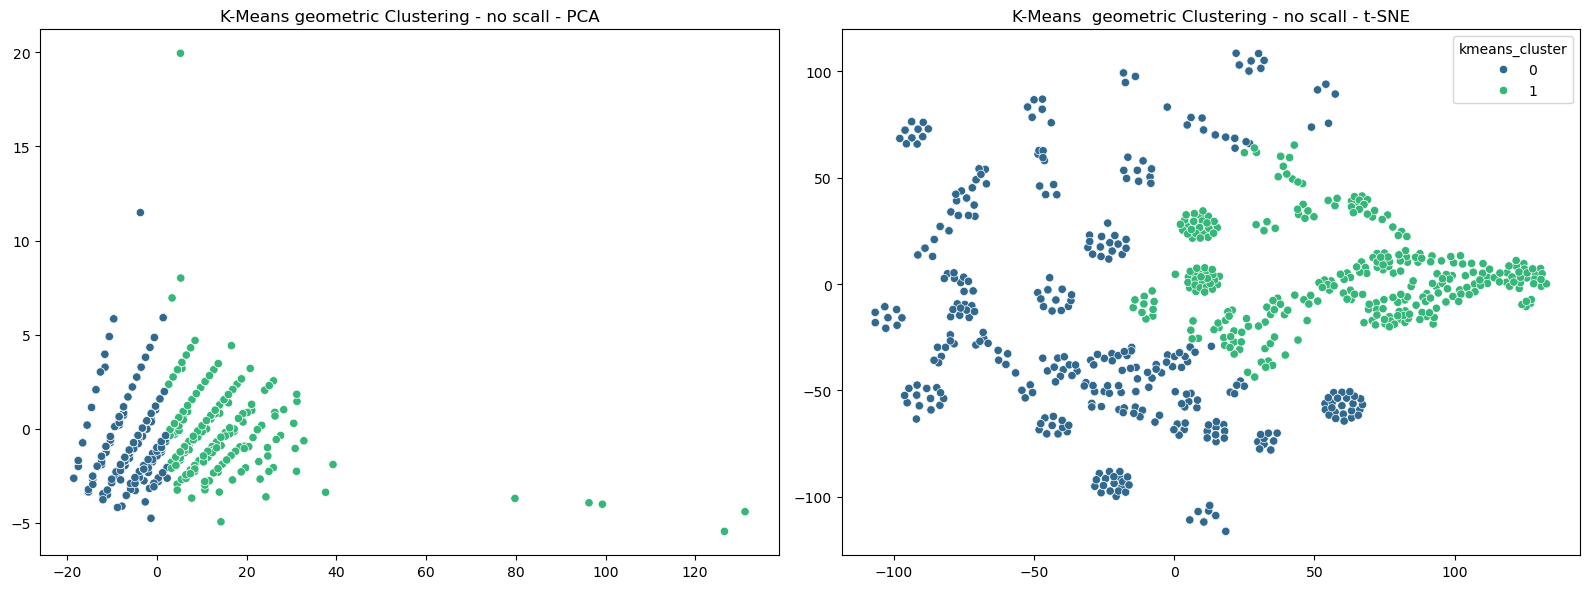

C:\Users\Original Computer\AppData\Local\Temp\ipykernel_1900\483764755.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sample['x'] = X_pca[:,0]
C:\Users\Original Computer\AppData\Local\Temp\ipykernel_1900\483764755.py:52: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sample['y'] = X_pca[:,1]


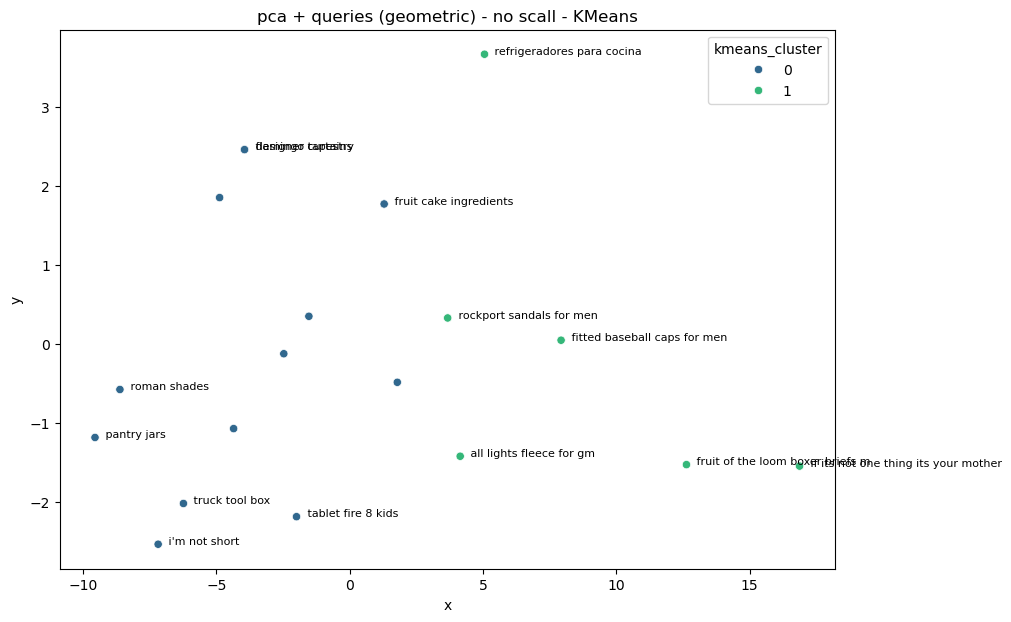

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

#to reduce size of showing graphes
sample_idx = np.random.choice(len(x), 1500, replace=False)
x_sample = x.iloc[sample_idx]
cluster_sample = data.iloc[sample_idx]['kmeans_cluster']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_sample)


tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(x_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[0],
    legend=False
)
axes[0].set_title("K-Means geometric Clustering - no scall - PCA")

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("K-Means  geometric Clustering - no scall - t-SNE")

plt.tight_layout()
plt.show()


# part2 with querise

sample = data.sample(n=20, random_state=17)
x_sample = x.iloc[sample.index]

X_pca = pca.fit_transform(x_sample)
sample['x'] = X_pca[:,0]
sample['y'] = X_pca[:,1]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=sample,
    x='x',
    y='y',
    hue='kmeans_cluster',
    palette='viridis'
)

# show only 2–3 labels per cluster
for cluster in sample['kmeans_cluster'].unique():
    cluster_points = sample[sample['kmeans_cluster'] == cluster].head(8)
    for _, row in cluster_points.iterrows():
        plt.text(row['x'], row['y'], "   "+row['query'], fontsize=8)

plt.title("pca + queries (geometric) - no scall - KMeans")
plt.show()

In [30]:
final_data.to_csv("ds/cleaned_amazon_queries_dataset_en_50k_geo_semant_umap.csv")